# Prescriptive Analytics for Diabetes Risk Prediction

This notebook extends the predictive model developed in the `predictive.ipynb` notebook by introducing a **prescriptive analytics framework**.

While the predictive model determines whether a patient is likely to be diabetic, prescriptive analytics focuses on **interpreting these predictions and supporting decision-making processes**.

The objectives of this notebook are:

1. Interpret the predictive model using **feature importance and SHAP explanations**
2. Develop **decision rules** inspired by expert systems
3. Simulate **policy interventions** and analyze their effect on model predictions
4. Evaluate how model performance changes under **distribution shifts**

The Random Forest model trained in `predictive.ipynb` will be reimplemented to ensure that this notebook is **self-contained and reproducible**.

In [42]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree

from imblearn.under_sampling import RandomUnderSampler

import shap

np.random.seed(1)

In [43]:
# Load dataset
diab_df = pd.read_csv("data/diabetes_012_health_indicators_BRFSS2015.csv")

In [44]:
diab_df["BPxChol"] = diab_df["HighBP"] * diab_df["HighChol"]

features = ["BPxChol", "Age", "GenHlth", "BMI"]

X = diab_df.loc[diab_df["Diabetes_012"].isin([0,2]), :]
y = diab_df.loc[diab_df["Diabetes_012"].isin([0,2]), "Diabetes_012"]

y[y == 2] = 1

undersampler = RandomUnderSampler()

X_resampled, y_resampled = undersampler.fit_resample(X, y)

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2
)

scaler = MinMaxScaler()

X_train_sc = scaler.fit_transform(X_train[features])
X_test_sc = scaler.transform(X_test[features])

### Training the Random Forest Model

A Random Forest classifier is used to reduce overfitting and improve generalization compared to a single decision tree.

Key parameters include:

- `criterion = "gini"`
- `max_features = "sqrt"`
- `max_leaf_nodes = 16`
- `max_depth = 6`
- `n_estimators = 100`

In [ ]:
model = RandomForestClassifier(
    criterion="gini",
    max_features='sqrt',
    max_leaf_nodes=16,
    max_depth=6,
    n_estimators=100
)

{'criterion': 'gini',
 'max_depth': 6,
 'max_features': 'sqrt',
 'max_leaf_nodes': 16,
 'n_estimators': 100}

## Feature Importance from the Random Forest Model

Before analyzing SHAP values, it is useful to examine the **feature importance scores** produced by the Random Forest model. These scores indicate how frequently each variable contributes to splitting the decision trees.

This provides a first overview of which health indicators influence the prediction of diabetes risk the most.

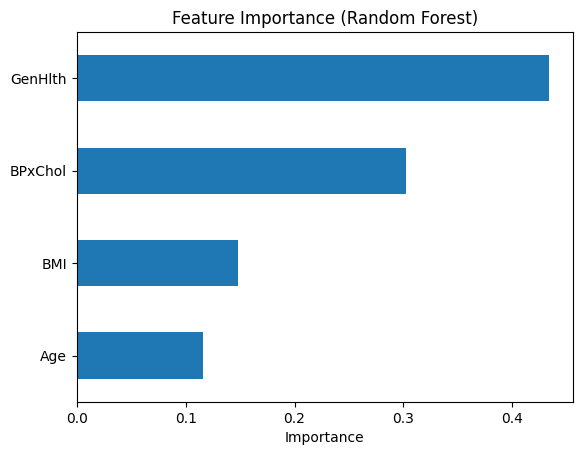

In [47]:
importance = model.feature_importances_

feat_importance = pd.Series(importance, index=features)

feat_importance.sort_values().plot(kind='barh')

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")

plt.show()

## Decision Tree Visualization

Although the Random Forest model consists of multiple trees, examining an individual tree helps illustrate how the model makes decisions.

The figure below displays one example decision tree from the Random Forest. Each node represents a decision rule based on one of the input features, while the leaves represent the final classification outcome.

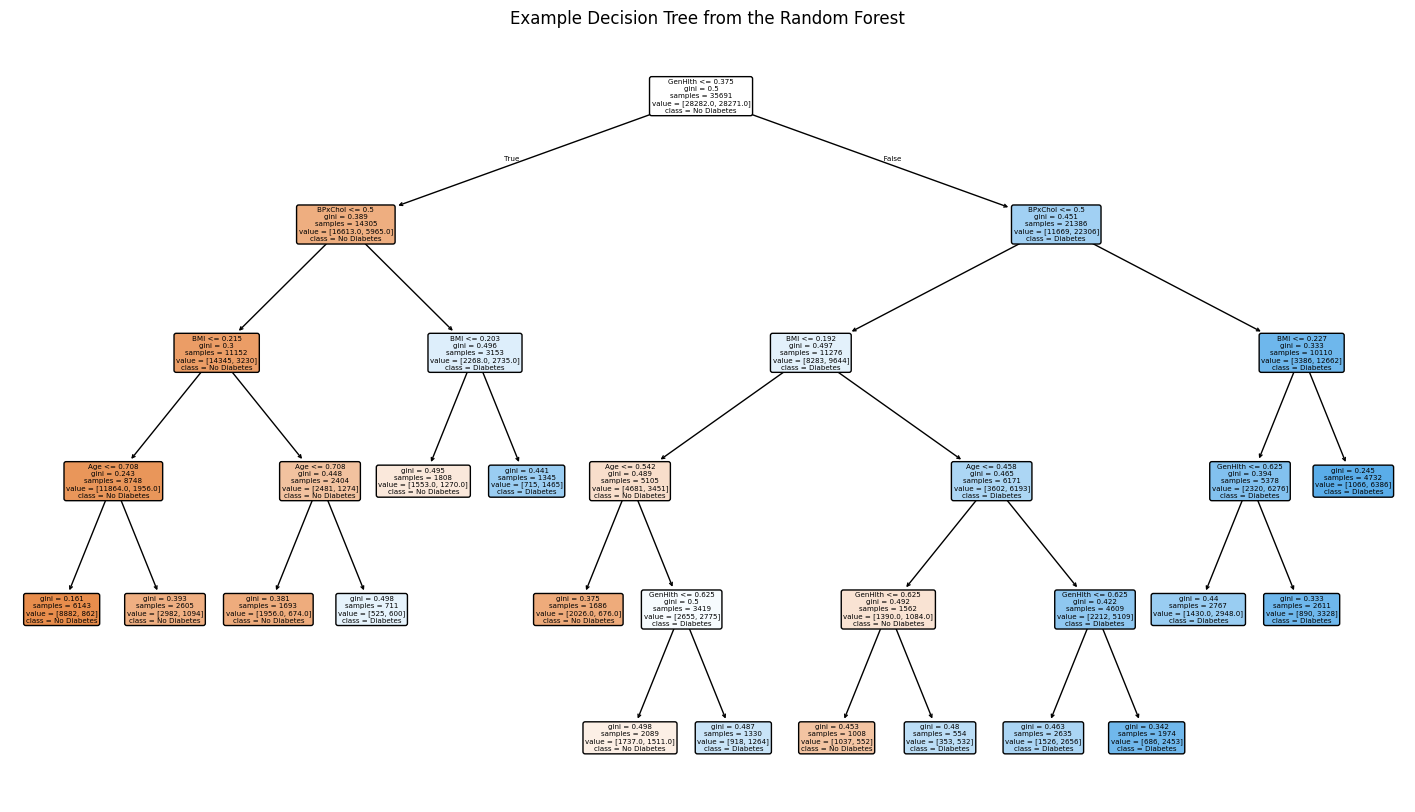

In [48]:
plt.figure(figsize=(18,10))

plot_tree(model.estimators_[0],
          feature_names=features,
          class_names=["No Diabetes","Diabetes"],
          filled=True,
          rounded=True)

plt.title("Example Decision Tree from the Random Forest")

plt.show()

## Model Performance Verification

Before interpreting the model in detail, its predictive performance is verified again using cross-validation and evaluation on the test dataset.

In [ ]:
# assess model performance with cross-validation
scoring = ['accuracy', 'f1_macro']
scores = cross_validate(model, X_train_sc, y_train, cv=5, scoring=scoring)

# train the model
model.fit(X_train_sc, y_train)

# predict on test set
y_pred = model.predict(X_test_sc)


Classification Report:
               precision    recall  f1-score   support

         0.0       0.73      0.73      0.73      7058
         1.0       0.73      0.73      0.73      7081

    accuracy                           0.73     14139
   macro avg       0.73      0.73      0.73     14139
weighted avg       0.73      0.73      0.73     14139



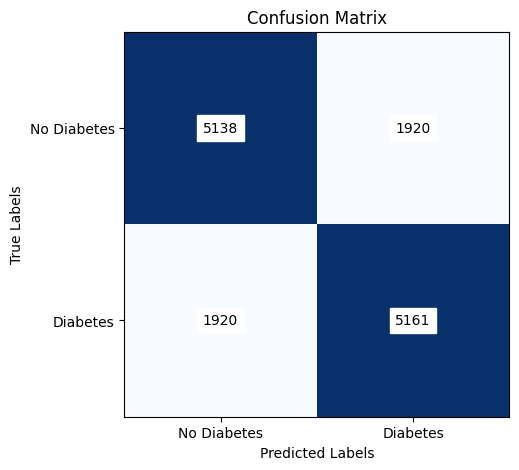

In [50]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(13, 5))

ticks = ["No Diabetes", "Diabetes"]

axes.imshow(conf_matrix, cmap='Blues', interpolation='None')
axes.set_title("Confusion Matrix")

axes.set_xticks(range(len(ticks)), ticks)
axes.set_yticks(range(len(ticks)), ticks)

axes.set_xlabel('Predicted Labels')
axes.set_ylabel('True Labels')

for (j,i),label in np.ndenumerate(conf_matrix):
    axes.text(i,j,label,ha='center',va='center', fontsize=10, backgroundcolor='white')

plt.show()

## Explaining the Model Using SHAP Values

To better understand the model’s predictions, **SHAP values** are calculated.

SHAP assigns each feature a value representing its contribution to the final prediction. These values are based on cooperative game theory and quantify how much each variable pushes the prediction toward either class.

This allows the model to be interpreted both **globally** (for the entire dataset) and **locally** (for a single individual prediction).

In [51]:
# explain the model with shap values
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test_sc)

columns=["BPxChol", "Age", "GenHlth", "BMI"]

shap_obj = shap.Explanation(values = shap_values.values[:,:,1],
                             base_values = explainer.expected_value[1],
                             data = scaler.inverse_transform(X_test_sc),
                             feature_names=columns)

## Global Feature Importance Using SHAP

The mean SHAP values provide a global measure of feature importance. They represent the average contribution of each variable to the model’s predictions across all observations.

/var/folders/3w/8fsd48l51sg5lw_r62023_n80000gn/T/ipykernel_58840/2577239588.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_obj, X_test_sc, plot_type="bar")


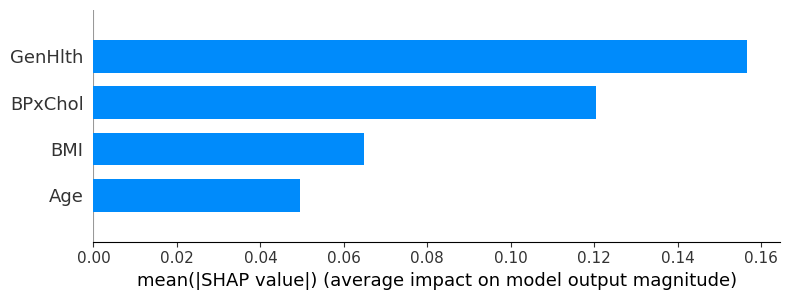

In [52]:
shap.initjs()

shap.summary_plot(shap_obj, X_test_sc, plot_type="bar")

## Local Explanation of an Individual Prediction

SHAP can also provide explanations for individual predictions.

The **waterfall plot** below illustrates how each feature contributes to the prediction for a single patient. Starting from the baseline prediction, each feature either increases or decreases the predicted probability of diabetes.

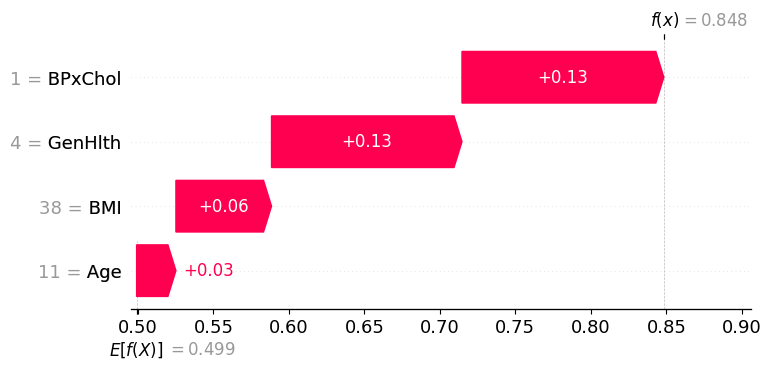

In [53]:
shap.plots.waterfall(shap_obj[40])

## SHAP Beeswarm Plot

The beeswarm plot shows how each feature influences the predictions across all observations.

Each dot represents a patient in the dataset, and the color represents the value of the feature. The position along the horizontal axis represents the SHAP value, indicating whether the feature increases or decreases the probability of being classified as diabetic.

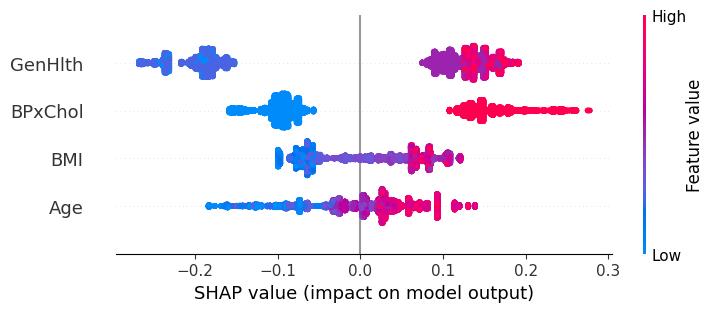

In [54]:
shap.plots.beeswarm(shap_obj)

## Feature-Level SHAP Analysis

Scatter plots can be used to examine how the value of each feature affects its SHAP value.

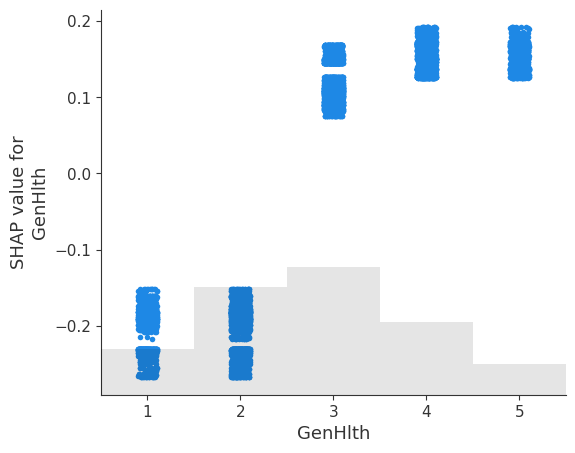

In [55]:
shap.plots.scatter(shap_obj[:, "GenHlth"])

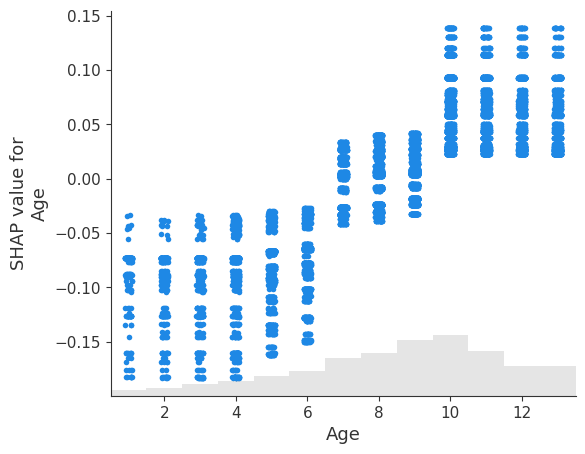

In [56]:
shap.plots.scatter(shap_obj[:, "Age"])

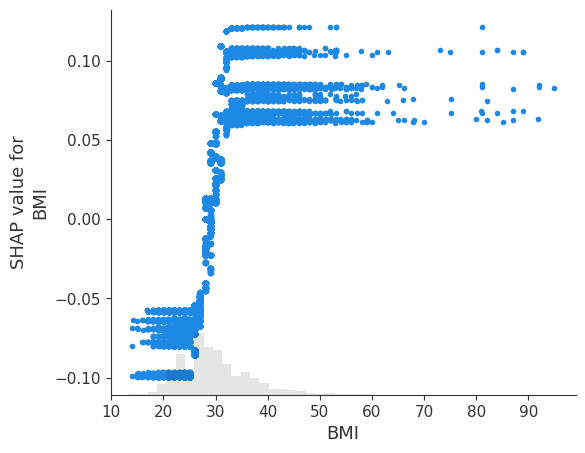

In [57]:
shap.plots.scatter(shap_obj[:, "BMI"])

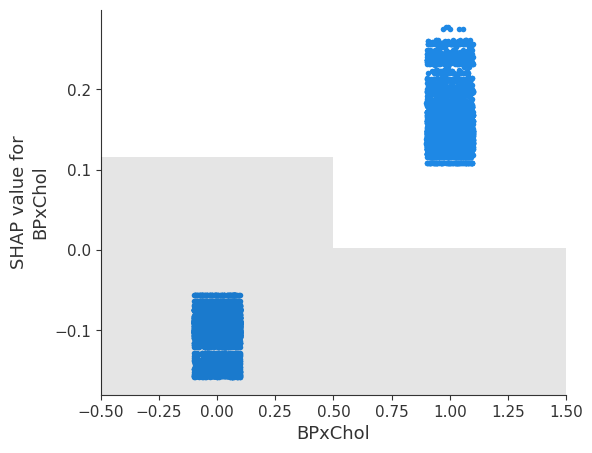

In [58]:
shap.plots.scatter(shap_obj[:, "BPxChol"])

## Testing Model Robustness Under Population Changes

In real-world scenarios, the characteristics of the population may change over time. For example, a successful public health intervention could lead to a reduction in average BMI levels across the population.

To simulate this scenario, BMI values in the test dataset are reduced by 10 units, creating a shifted distribution representing a healthier population.

In [59]:
# testing the model shifting BMI to 10 values lower

X_test_shifted = X_test.copy()

X_test_shifted["BMI"] = X_test["BMI"] - 10

X_test_sc_shifted = scaler.transform(X_test_shifted[features])

In [60]:
y_pred_shifted = model.predict(X_test_sc_shifted)

print("\nClassification Report:\n", classification_report(y_test, y_pred_shifted))


Classification Report:
               precision    recall  f1-score   support

         0.0       0.64      0.85      0.73      7058
         1.0       0.78      0.52      0.62      7081

    accuracy                           0.69     14139
   macro avg       0.71      0.69      0.68     14139
weighted avg       0.71      0.69      0.68     14139



## New BMI Distribution

The following histogram illustrates the new BMI distribution after the simulated health intervention.

<Axes: xlabel='BMI', ylabel='Count'>

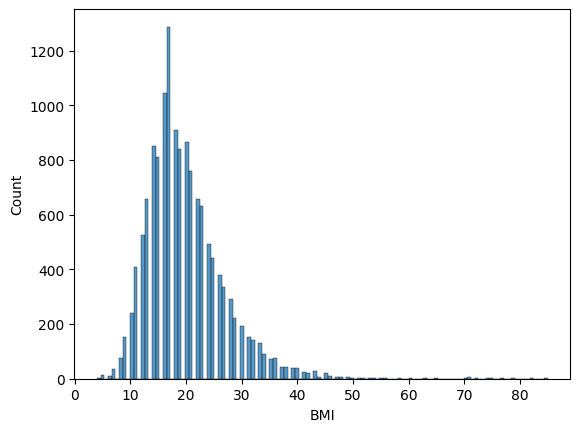

In [61]:
sns.histplot(X_test_shifted["BMI"])

## Interpretation

The results show that the model's performance decreases when the BMI distribution shifts. Both **accuracy and F1-score decline**, indicating that the model is sensitive to changes in the underlying population characteristics.

This suggests that BMI is an important predictor within the model. When its distribution changes significantly, the model's predictive power is affected.

Such results highlight the importance of **continuous monitoring and retraining of predictive models**, especially when applied in dynamic environments such as healthcare systems.

Furthermore, these findings demonstrate the necessity of combining machine learning models with **human oversight**, ensuring that automated systems support rather than replace professional medical judgment.